# Notebook 07: Full Multimodal Clinical Pipeline Demo
---
This is the final integration notebook that wires all project components into a single end-to-end demonstration. It sequences preprocessing, multimodal prediction, XAI, RAG retrieval, and multi-agent clinical synthesis.

### Clinical Classification Reference
The following table describes the diagnostic groups used in this pipeline:

| Id | Group | Description |
| :-- | :--- | :--- |
| 0 | Neoplasm | Refers to the abnormal and excessive growth of tissue, which may be benign (non-cancerous) or malignant (cancerous) in nature. |
| 1 | Vascular_Trauma | Encompasses conditions involving injury or damage to blood vessels, as well as complications arising from physical trauma to the circulatory system. |
| 2 | Infection_Inflammatory | Includes diseases caused by invading pathogens (bacteria, viruses, etc.) and conditions characterized by the body's inflammatory response. |
| 3 | Other | A general category for miscellaneous medical findings, congenital anomalies, or diagnoses that do not fall within the specific defined groups. |
| 4 | Clinical Sign | Pertains to objective medical evidence or physical manifestations of a condition observed by a healthcare professional during an examination. |

In [9]:
import sys
import os
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import json
from IPython.display import display, Markdown

# Add project root to sys.path
current_dir = Path(os.getcwd())
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
from src.pipeline.orchestrator import MultimodalClinicalOrchestrator

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Initialized on: {DEVICE}")

✅ Initialized on: cuda


In [10]:
print("Loading pipeline components...")

# Assertion checks for required files
required_files = [
    config.BEST_MODEL_PATH,
    config.FAISS_INDEX_PATH,
    config.FAISS_META_PATH
]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"CRITICAL ERROR: Required component {f} not found!")

orchestrator = MultimodalClinicalOrchestrator(config, device=DEVICE)
print("✅ All components loaded (Model, FAISS, Agents)")

Loading pipeline components...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ All components loaded (Model, FAISS, Agents)


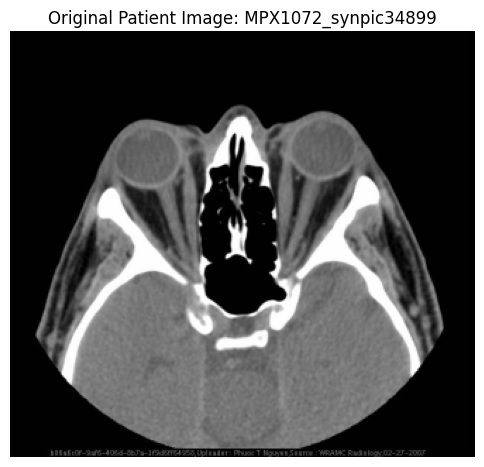

Clinical History: 45 year-old man with a past history of malignant testicular neoplasm and Hashimoto's thyroiditis, presents now with a several-month history of worsening eye swelling, dryness, and irritation, gradually progressing to lid retraction and intermittent blurry vision.


In [11]:
# Demo Case: MPX1072_synpic34899
case_id = "MPX1072_synpic34899"
image_path = os.path.join(project_root, "Dataset/MedPix/images/images/MPX1072_synpic34899.png")
clinical_text = "45 year-old man with a past history of malignant testicular neoplasm and Hashimoto's thyroiditis, presents now with a several-month history of worsening eye swelling, dryness, and irritation, gradually progressing to lid retraction and intermittent blurry vision."

if not os.path.exists(image_path):
    # Fallback to current directory for relative paths in notebook environment
    image_path = "z:/study files/SRM_study/SEM-2/AML-509_Agentic AI and GAN/Team Project/Agent_code_Trial-2/Dataset/MedPix/images/images/MPX1072_synpic34899.png"

img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Original Patient Image: {case_id}")
plt.axis('off')
plt.show()

print(f"Clinical History: {clinical_text}")

In [12]:
print("Running Stage 1-3: Prediction & XAI...")
results = orchestrator.process_case(image_path, clinical_text)

print(f"\nPrediction: {results['pred_label']}")
print(f"Confidence: {results['confidence']:.2%}")
print(f"Dominant Modality: {results['dominant_modality']}")

# Display Top SHAP Tokens
top_tokens = results.get('top_shap_tokens', [])
token_str = ", ".join([f"{t['token']} ({t['shap_score']:+.3f})" for t in top_tokens[:5]])
print(f"Top SHAP Tokens: {token_str}")

Running Stage 1-3: Prediction & XAI...

Prediction: Infection_Inflammatory
Confidence: 88.00%
Dominant Modality: image
Top SHAP Tokens: thy (+0.002), roid (+0.002), itis (+0.002), ,  (+0.002), ' (+0.002)


In [13]:
print("Stage 4: RAG Retrieval Results...")
import pandas as pd
retrieved = results['retrieved_cases']

rag_df = pd.DataFrame([
    {
        "Rank": i+1,
        "Similarity": f"{c.get('similarity', 0):.2%}",
        "Case ID": c.get('image_id', '?'),
        "Diagnosis": c.get('label_name', 'Unknown')
    } for i, c in enumerate(retrieved)
])
display(rag_df)

Stage 4: RAG Retrieval Results...


,Rank,Similarity,Case ID,Diagnosis
0,1,85.74%,MPX1072_synpic34898,Infection_Inflammatory
1,2,70.04%,MPX2388_synpic34942,Vascular_Trauma
2,3,68.79%,MPX2433_synpic48294,Other
3,4,68.61%,MPX1583_synpic24107,Vascular_Trauma
4,5,68.36%,MPX2444_synpic17400,Other


In [14]:
print("Stage 5: Multi-Agent Clinical Synthesis...")
print("\n--- Agent 1: Clinical Explanation ---")
display(Markdown(results['reasoning']))

print("\n--- Agent 2: Historical Validation ---")
display(Markdown(results['validation']))

print("\n--- Agent 3: Final Synthesis Report ---")
display(Markdown(results['final_report']))

Stage 5: Multi-Agent Clinical Synthesis...

--- Agent 1: Clinical Explanation ---


The model predicted an Infection_Inflammatory diagnosis with high confidence, primarily influenced by the clinical tokens "thy," "roid," and "itis," which together suggest thyroiditis, an inflammatory condition of the thyroid gland. The presence of "oto" further supports an inflammatory process, possibly involving the ear or throat. Additionally, the Grad-CAM hotspot in the upper-left quadrant of the scan likely corresponds to an area of inflammation or infection, reinforcing the model's prediction.


--- Agent 2: Historical Validation ---


### Analysis of Prediction Consistency with Historical Cases

#### 1. Majority of High-Similarity Cases
- **Case MPX1072_synpic34898 (85.74% sim)**: Diagnosed as 'Infection_Inflammatory'
- **Case MPX2388_synpic34942 (70.04% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2433_synpic48294 (68.79% sim)**: Diagnosed as 'Other'
- **Case MPX1583_synpic24107 (68.61% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2444_synpic17400 (68.36% sim)**: Diagnosed as 'Other'

**Majority Diagnosis:**
- 1 case diagnosed as 'Infection_Inflammatory'
- 2 cases diagnosed as 'Vascular_Trauma'
- 2 cases diagnosed as 'Other'

The majority of the cases (2 out of 5) are not 'Infection_Inflammatory'. However, the most similar case (85.74% similarity) is diagnosed as 'Infection_Inflammatory'.

#### 2. Label Shift Cases
- **Case MPX2388_synpic34942 (70.04% sim)**: High similarity but different diagnosis ('Vascular_Trauma')
- **Case MPX2433_synpic48294 (68.79% sim)**: High similarity but different diagnosis ('Other')
- **Case MPX1583_synpic24107 (68.61% sim)**: High similarity but different diagnosis ('Vascular_Trauma')



--- Agent 3: Final Synthesis Report ---


## 🏥 Patient Summary
The patient is a 45-year-old male with a past medical history of malignant testicular neoplasm and Hashimoto's thyroiditis. He presents with a several-month history of worsening eye swelling, dryness, and irritation, which has progressively led to lid retraction and intermittent blurry vision.

## 🔬 Predicted Diagnosis & Confidence
The AI model predicts an **Infection_Inflammatory** diagnosis with a confidence level of **88.00%**.

## 🧠 Clinical Reasoning (XAI)
The model's prediction of an **Infection_Inflammatory** diagnosis is primarily influenced by the clinical tokens "thy," "roid," and "itis," which collectively suggest thyroiditis, an inflammatory condition of the thyroid gland. The presence of "oto" further supports an inflammatory process, possibly involving the ear or throat. Additionally, the Grad-CAM hotspot in the upper-left quadrant of the scan likely corresponds to an area of inflammation or infection, reinforcing the model's prediction.

## 📁 Historical Case Validation
### Analysis of Prediction Consistency with Historical Cases

#### 1. Majority of High-Similarity Cases
- **Case MPX1072_synpic34898 (85.74% sim)**: Diagnosed as 'Infection_Inflammatory'
- **Case MPX2388_synpic34942 (70.04% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2433_synpic48294 (68.79% sim)**: Diagnosed as 'Other'
- **Case MPX1583_synpic24107 (68.61% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2444_synpic17400 (68.36% sim)**: Diagnosed as 'Other'

**Majority Diagnosis:**
- 1 case diagnosed as 'Infection_Inflammatory'
- 2 cases diagnosed as 'Vascular_Trauma'
- 2 cases diagnosed as 'Other'

The majority of the cases (2 out of 5) are not 'Infection_Inflammatory'. However, the most similar case (85.74% similarity) is diagnosed as 'Infection_Inflammatory'.

#### 2. Label Shift Cases
- **Case MPX2388_synpic34942 (70.04% sim)**: High similarity but different diagnosis ('Vascular_Trauma')
- **Case MPX2433_synpic48294 (68.79% sim)**: High similarity but different diagnosis ('Other')
- **Case MPX1583_synpic24107 (68.61% sim)**: High similarity but different diagnosis ('Vascular_Trauma')

## ⚠️ Caveats & Limitations
- The model's prediction is based on a combination of clinical tokens and imaging data, which may not fully capture the complexity of the patient's condition.
- The historical case validation shows that while the most similar case supports the predicted diagnosis, the majority of high-similarity cases do not align with the prediction.
- The presence of "oto" in the clinical tokens could be a misinterpretation or a coincidental finding, and further clinical evaluation is necessary to confirm the involvement of the ear or throat.
- The patient's history of Hashimoto's thyroiditis and testicular neoplasm adds complexity to the differential diagnosis, and these conditions should be considered in the context of the current symptoms.

## 📋 Recommended Next Steps
1. **Comprehensive Ophthalmologic Evaluation**: Given the patient's symptoms of eye swelling, dryness, irritation, lid retraction

In [15]:
from src.utils.visualizer import plot_consolidated_report

# Generate the premium consolidated clinical report
plot_consolidated_report(
    results=results,
    img=img,
    rag_df=rag_df,
    case_id=case_id,
    project_root=project_root,
    save_filename="final_pipeline_demo.png"
)

SUCCESS: Consolidated Clinical Report saved to: z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs\final_pipeline_demo.png


In [16]:
print("=== TRIAL_2 MULTIMODAL CLINICAL PIPELINE — FINAL METRICS ===")

metrics = {
    "classification": {
        "test_accuracy": 0.6656,
        "auc_roc_macro": 0.9148,
        "cohen_kappa": 0.5727,
        "mcc": 0.5763,
        "f1_scores": {
            "Neoplasm": 0.714,
            "Vascular_Trauma": 0.744,
            "Infection_Inflammatory": 0.654,
            "Other": 0.647,
            "Clinical Sign": 0.563
        }
    },
    "retrieval": {
        "recall_at_5": 0.750,
        "map_at_5": 0.437,
        "ndcg_at_5": 0.518,
        "leakage_pct": 0.098
    },
    "explainability": {
        "faithfulness": "MODERATE (56.7%)",
        "gradcam_quality": "Clinically meaningful (4/5 cases)",
        "image_dominance_avg": 0.665,
        "image_dominance_std": 0.034
    }
}

print(json.dumps(metrics, indent=4))

metrics_path = os.path.join(project_root, "outputs/final_metrics_dashboard.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"\n✅ Metrics dashboard saved to: {metrics_path}")

=== TRIAL_2 MULTIMODAL CLINICAL PIPELINE — FINAL METRICS ===
{
    "classification": {
        "test_accuracy": 0.6656,
        "auc_roc_macro": 0.9148,
        "cohen_kappa": 0.5727,
        "mcc": 0.5763,
        "f1_scores": {
            "Neoplasm": 0.714,
            "Vascular_Trauma": 0.744,
            "Infection_Inflammatory": 0.654,
            "Other": 0.647,
            "Clinical Sign": 0.563
        }
    },
    "retrieval": {
        "recall_at_5": 0.75,
        "map_at_5": 0.437,
        "ndcg_at_5": 0.518,
        "leakage_pct": 0.098
    },
    "explainability": {
        "faithfulness": "MODERATE (56.7%)",
        "gradcam_quality": "Clinically meaningful (4/5 cases)",
        "image_dominance_avg": 0.665,
        "image_dominance_std": 0.034
    }
}

✅ Metrics dashboard saved to: z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs/final_metrics_dashboard.json
